# Univariate & Bivariate Exploratory Data Analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [3]:
sns.set_theme(style="whitegrid")

df = pd.read_parquet("../data/processed/taxi_trip_cleaned.parquet")
print("Dataset shape:", df.shape)
display(df.head())
display(df.dtypes)

Dataset shape: (3724888, 36)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,pickup_hour,pickup_day,pickup_day_name,pickup_weekday,pickup_month,pickup_year,pickup_period,average_speed_mph,fare_per_mile,is_weekend
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,...,0,1,Thursday,3,1,2026,Night,10.486486,7.422680,False
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0,0.90,1.0,N,163,162,2,...,0,1,Thursday,3,1,2026,Night,9.446064,8.777778,False
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0,1.40,1.0,N,43,237,1,...,0,1,Thursday,3,1,2026,Night,9.455910,7.642857,False
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,...,0,1,Thursday,3,1,2026,Night,7.822430,6.935484,False
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0.0,2.16,1.0,N,88,144,1,...,0,1,Thursday,3,1,2026,Night,9.600000,6.250000,False


VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag                  str
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
Airport_fee                     float64
cbd_congestion_fee              float64
trip_duration_minutes           float64
zero_duration_flag                 bool
zero_distance_flag                 bool
extreme_distance_flag              bool
long_duration_flag                 bool


In [3]:
[c for c in df.columns if "duration" in c.lower()]

['trip_duration_minutes', 'zero_duration_flag', 'long_duration_flag']

## Univariate Analysis

In [25]:
distance = df["trip_distance"].dropna()

display(
    distance.describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.999]
    )
)

print("Skewness:", distance.skew())
print("Zero-distance trips:", (distance == 0).sum())
print("Negative-distance trips:", (distance < 0).sum())

count    3.724888e+06
mean     6.455644e+00
std      6.488856e+02
min      0.000000e+00
25%      1.000000e+00
50%      1.810000e+00
75%      3.730000e+00
90%      8.560000e+00
95%      1.245000e+01
99%      1.954000e+01
99.9%    2.979000e+01
max      2.690975e+05
Name: trip_distance, dtype: float64

Skewness: 243.67327340249963
Zero-distance trips: 125738
Negative-distance trips: 0


In [26]:
distance.median()

np.float64(1.81)

In [30]:
print("Extreme distance observations:")
print(df["extreme_distance_flag"].sum())

Extreme distance observations:
421949


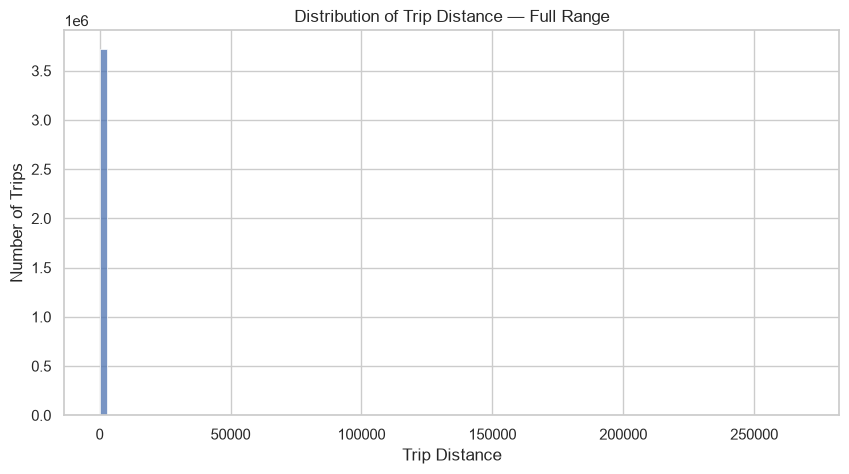

In [5]:
plt.figure(figsize=(10, 5))
sns.histplot(distance, bins=100)
plt.title("Distribution of Trip Distance — Full Range")
plt.xlabel("Trip Distance")
plt.ylabel("Number of Trips")
plt.show()

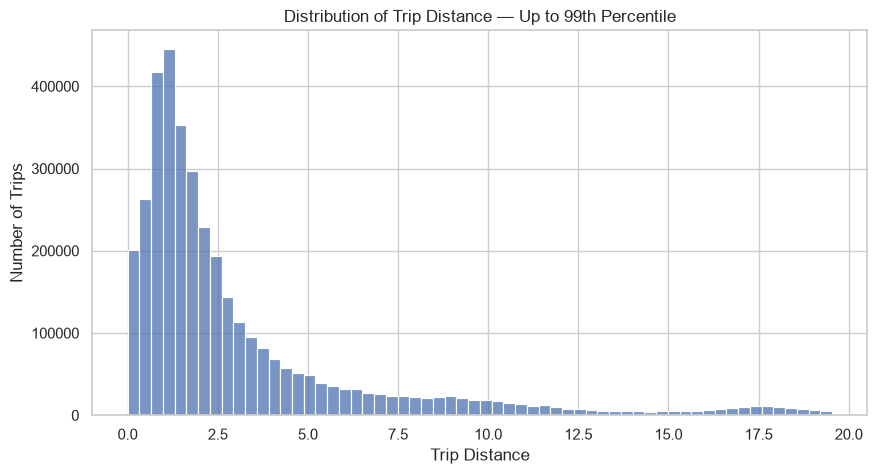

99th percentile: 19.54
Maximum distance: 269097.48


In [6]:
q99 = distance.quantile(0.99)
distance_central = distance[distance <= q99]

plt.figure(figsize=(10, 5))
sns.histplot(distance_central, bins=60)
plt.title("Distribution of Trip Distance — Up to 99th Percentile")
plt.xlabel("Trip Distance")
plt.ylabel("Number of Trips")
plt.show()

print("99th percentile:", q99)
print("Maximum distance:", distance.max())

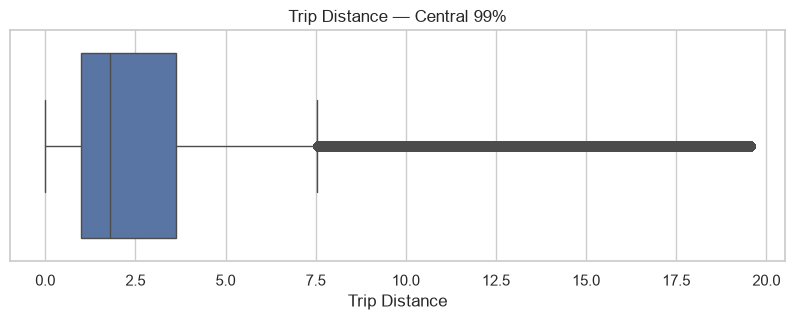

In [7]:
plt.figure(figsize=(10, 3))
sns.boxplot(x=distance_central)
plt.title("Trip Distance — Central 99%")
plt.xlabel("Trip Distance")
plt.show()

In [8]:
[c for c in df.columns if "duration" in c.lower()]

['trip_duration_minutes', 'zero_duration_flag', 'long_duration_flag']

In [9]:
duration = df["trip_duration_minutes"].dropna()

display(
    duration.describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

print("Skewness:", duration.skew())

count    3.724888e+06
mean     1.719317e+01
std      2.517802e+01
min      0.000000e+00
25%      8.066667e+00
50%      1.336667e+01
75%      2.120000e+01
90%      3.225000e+01
95%      4.275000e+01
99%      7.143333e+01
max      7.507900e+03
Name: trip_duration_minutes, dtype: float64

Skewness: 51.19000014923694


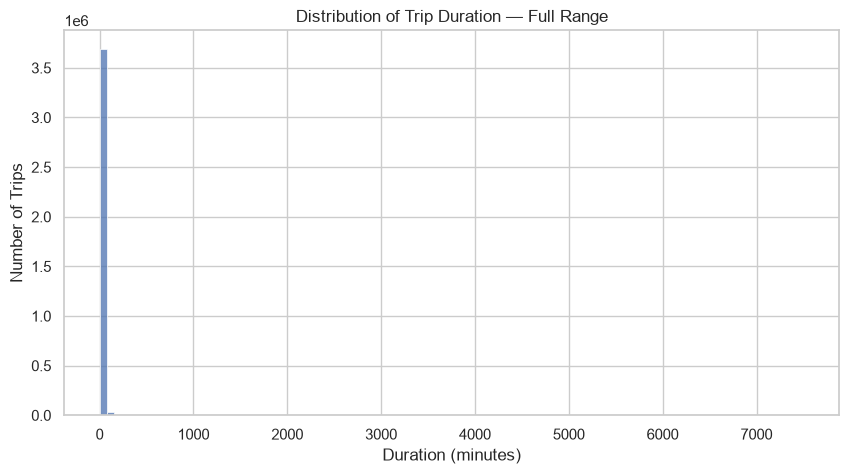

In [10]:
plt.figure(figsize=(10, 5))
sns.histplot(duration, bins=100)
plt.title("Distribution of Trip Duration — Full Range")
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Trips")
plt.show()

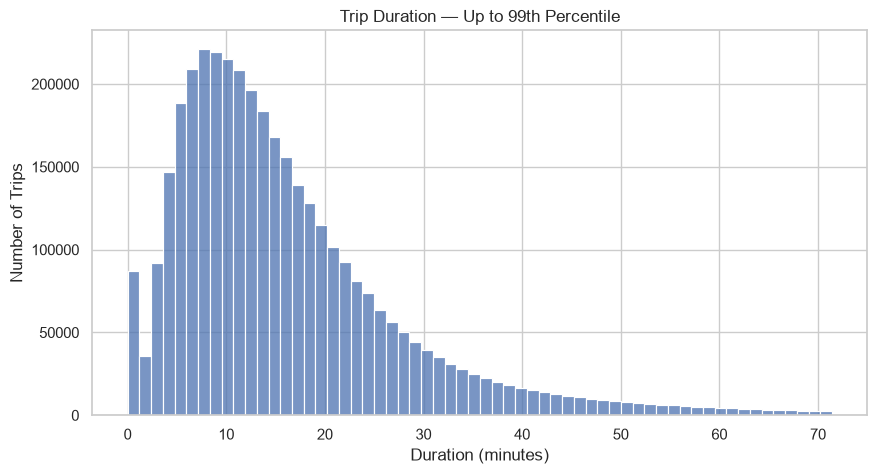

In [11]:
duration_q99 = duration.quantile(0.99)
duration_central = duration[duration <= duration_q99]

plt.figure(figsize=(10, 5))
sns.histplot(duration_central, bins=60)
plt.title("Trip Duration — Up to 99th Percentile")
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Trips")
plt.show()

In [12]:
numeric_columns = ["fare_amount", "total_amount"]

for column in numeric_columns:
    values = df[column].dropna()

    print(f"\n{column}")
    display(values.describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    ))
    print("Skewness:", values.skew())


fare_amount


count    3.724888e+06
mean     2.080424e+01
std      1.892699e+01
min     -2.555200e+03
25%      1.000000e+01
50%      1.560000e+01
75%      2.610000e+01
90%      4.219000e+01
95%      5.850000e+01
99%      8.140000e+01
max      2.555200e+03
Name: fare_amount, dtype: float64

Skewness: 3.374689402633977

total_amount


count    3.724888e+06
mean     2.917852e+01
std      2.258552e+01
min     -2.560200e+03
25%      1.700000e+01
50%      2.305000e+01
75%      3.383000e+01
90%      5.341000e+01
95%      7.525000e+01
99%      1.047500e+02
max      2.560200e+03
Name: total_amount, dtype: float64

Skewness: 2.95780183152308


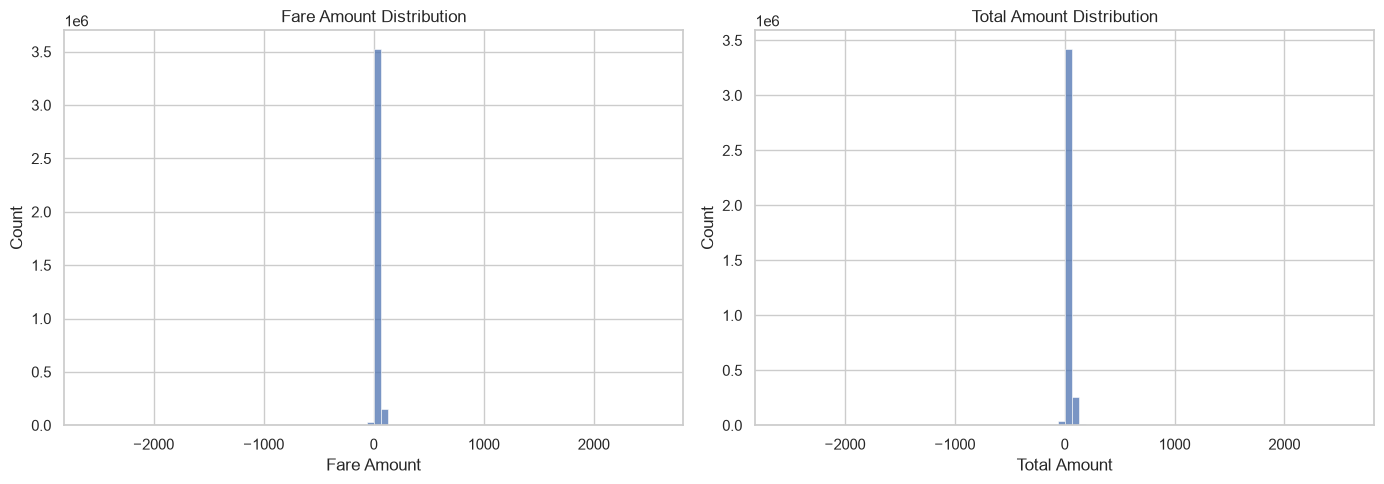

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["fare_amount"].dropna(), bins=80, ax=axes[0])
axes[0].set_title("Fare Amount Distribution")
axes[0].set_xlabel("Fare Amount")

sns.histplot(df["total_amount"].dropna(), bins=80, ax=axes[1])
axes[1].set_title("Total Amount Distribution")
axes[1].set_xlabel("Total Amount")

plt.tight_layout()
plt.show()

In [14]:
display(df["passenger_count"].value_counts(dropna=False).sort_index())

passenger_count
0.0      14787
1.0    2150993
2.0     334370
3.0      72864
4.0      49738
5.0       9184
6.0       4887
7.0          2
8.0          4
9.0          1
NaN    1088058
Name: count, dtype: int64

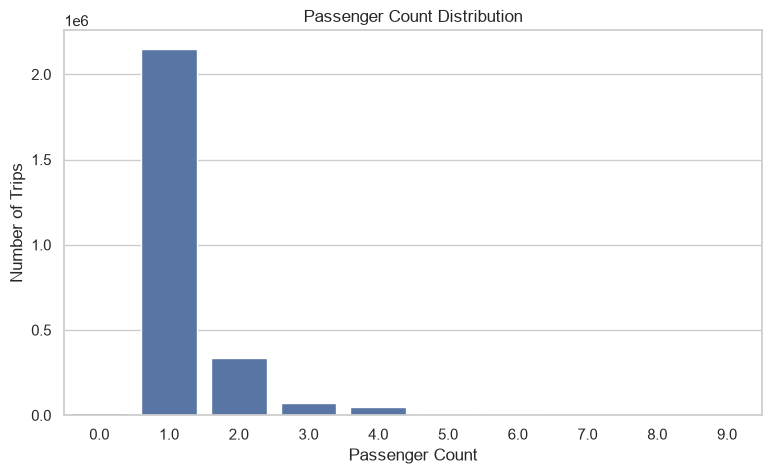

In [15]:
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x="passenger_count")
plt.title("Passenger Count Distribution")
plt.xlabel("Passenger Count")
plt.ylabel("Number of Trips")
plt.show()

In [16]:
payment_counts = df["payment_type"].value_counts(dropna=False).sort_index()
display(payment_counts)

payment_type
0    1088058
1    2249746
2     314043
3      16641
4      56400
Name: count, dtype: int64

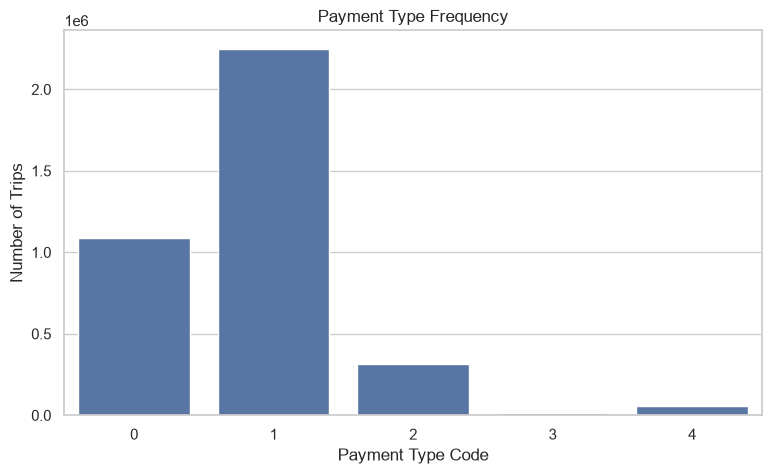

In [17]:
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x="payment_type", order=payment_counts.index)
plt.title("Payment Type Frequency")
plt.xlabel("Payment Type Code")
plt.ylabel("Number of Trips")
plt.show()

In [18]:
missing_percent = df.isna().mean().mul(100).sort_values(ascending=False)

display(
    missing_percent[missing_percent > 0]
    .to_frame("missing_percentage")
)

,missing_percentage
passenger_count,29.210489
congestion_surcharge,29.210489
store_and_fwd_flag,29.210489
RatecodeID,29.210489
Airport_fee,29.210489
fare_per_mile,3.375618
average_speed_mph,1.209942


# Bivariate Analysis

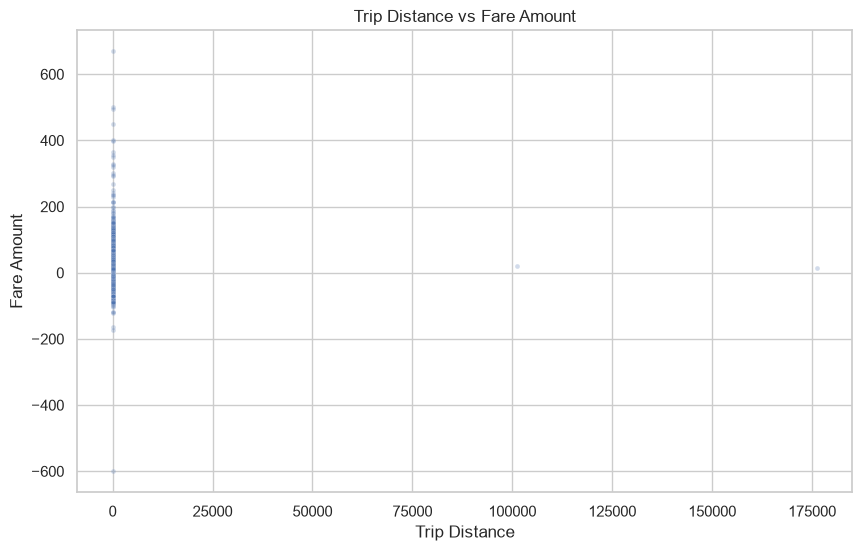

In [3]:
# Trip distance vs fare amount scatter plot
plot_df = df[["trip_distance", "fare_amount"]].dropna()

plot_sample = plot_df.sample(
    n=min(50_000, len(plot_df)),
    random_state=42
)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=plot_sample,
    x="trip_distance",
    y="fare_amount",
    alpha=0.25,
    s=12
)
plt.title("Trip Distance vs Fare Amount")
plt.xlabel("Trip Distance")
plt.ylabel("Fare Amount")
plt.show()

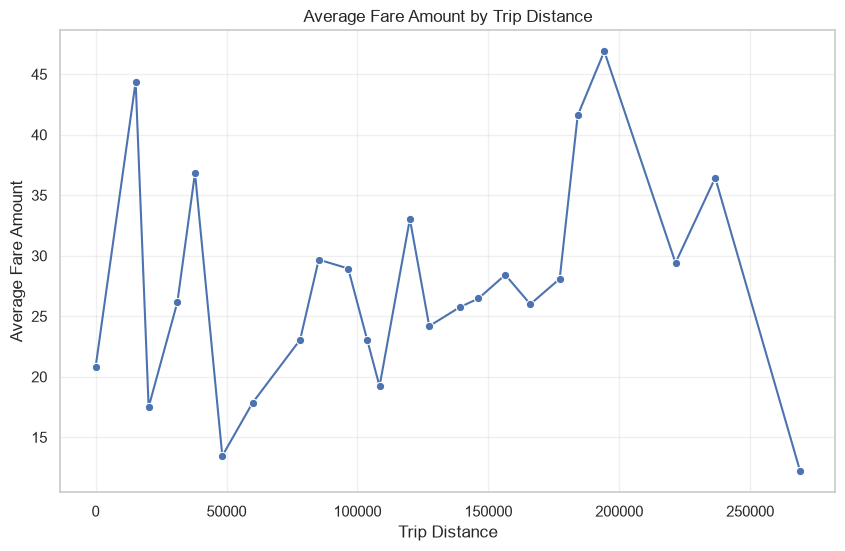

In [28]:
# Trip distance vs average fare amount - line plot

plot_df = df[["trip_distance", "fare_amount"]].dropna()

# Create distance bins
plot_df["distance_bin"] = pd.cut(
    plot_df["trip_distance"],
    bins=30
)

# Calculate average fare for each distance bin
line_df = (
    plot_df
    .groupby("distance_bin", observed=True)
    .agg(
        avg_fare=("fare_amount", "mean"),
        avg_distance=("trip_distance", "mean")
    )
    .reset_index()
)

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=line_df,
    x="avg_distance",
    y="avg_fare",
    marker="o"
)

plt.title("Average Fare Amount by Trip Distance")
plt.xlabel("Trip Distance")
plt.ylabel("Average Fare Amount")
plt.grid(alpha=0.3)

plt.show()

In [8]:
print(
    "Pearson correlation:",
    plot_df["trip_distance"].corr(plot_df["fare_amount"], method="pearson")
)

spearman = plot_df["trip_distance"].rank().corr(
    plot_df["fare_amount"].rank(),
    method="pearson"
)
print(
    "Spearman correlation:", spearman
)

Pearson correlation: 0.006715937064547035
Spearman correlation: 0.7605791972621613


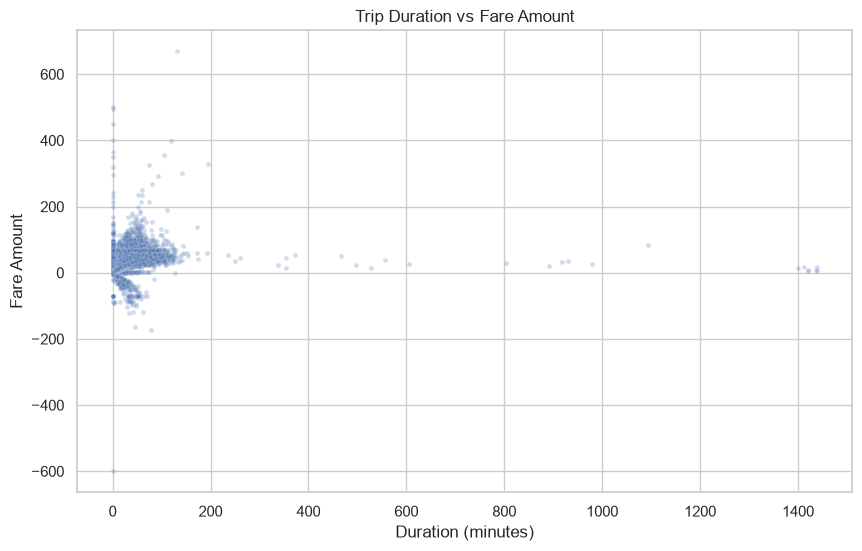

In [ ]:
duration_column = "trip_duration_minutes" 

duration_fare = df[[duration_column, "fare_amount"]].dropna()

sample = duration_fare.sample(
    n=min(50_000, len(duration_fare)),
    random_state=42
)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=sample,
    x=duration_column,
    y="fare_amount",
    alpha=0.25,
    s=12
)
plt.title("Trip Duration vs Fare Amount")
plt.xlabel("Duration (minutes)")
plt.ylabel("Fare Amount")
plt.show()

In [10]:
print(
    "Pearson:",
    duration_fare[duration_column].corr(
        duration_fare["fare_amount"], method="pearson"
    )
)

print(
    "Spearman:",
    duration_fare[duration_column].rank().corr(
        duration_fare["fare_amount"].rank(), method="pearson"
    )
)


Pearson: 0.3564263426674067
Spearman: 0.8483702427241673


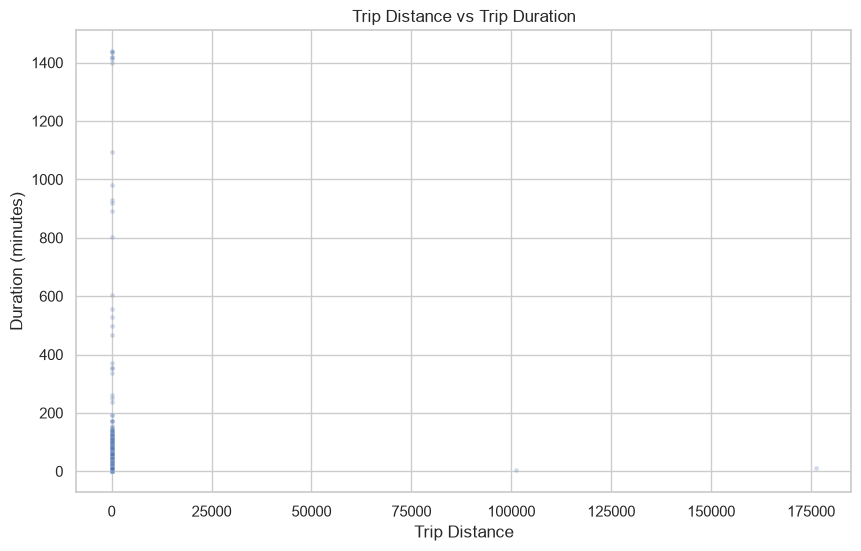

In [12]:
#Trip distance vs trip durationd
distance_duration = df[["trip_distance", duration_column]].dropna()

sample = distance_duration.sample(
    n=min(50_000, len(distance_duration)),
    random_state=42
)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=sample,
    x="trip_distance",
    y=duration_column,
    alpha=0.25,
    s=12
)
plt.title("Trip Distance vs Trip Duration")
plt.xlabel("Trip Distance")
plt.ylabel("Duration (minutes)")
plt.show()

In [13]:
display(
    distance_duration.corr(method="pearson")
)

display(
    distance_duration.rank().corr(method="pearson")
)

,trip_distance,trip_duration_minutes
trip_distance,1.000000,0.003329
trip_duration_minutes,0.003329,1.000000


,trip_distance,trip_duration_minutes
trip_distance,1.000000,0.766013
trip_duration_minutes,0.766013,1.000000


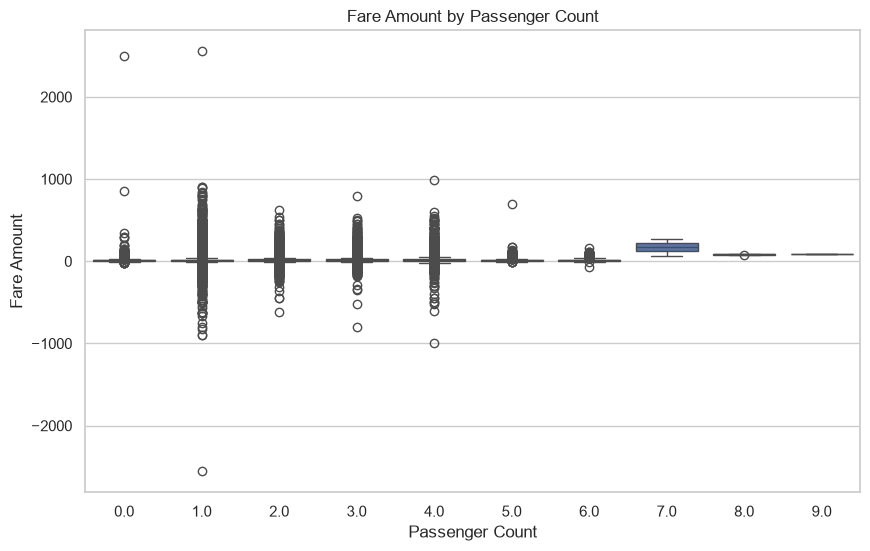

In [14]:
#Passenger count vs fare amount
passenger_fare = df[
    ["passenger_count", "fare_amount"]
].dropna()

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=passenger_fare,
    x="passenger_count",
    y="fare_amount"
)
plt.title("Fare Amount by Passenger Count")
plt.xlabel("Passenger Count")
plt.ylabel("Fare Amount")
plt.show()

In [15]:
display(
    passenger_fare.groupby("passenger_count")["fare_amount"]
    .agg(["count", "median", "mean", "std"])
)

,count,median,mean,std
passenger_count,,,,
0.0,14787,12.1,16.472925,26.138577
1.0,2150993,12.8,18.448492,19.140495
2.0,334370,13.5,20.797010,22.528803
3.0,72864,13.5,20.771463,25.240214
4.0,49738,14.2,25.031546,32.880713
5.0,9184,12.1,16.820561,16.194917
6.0,4887,12.1,17.488500,16.173197
7.0,2,170.0,170.000000,141.421356
8.0,4,83.0,82.500000,1.732051


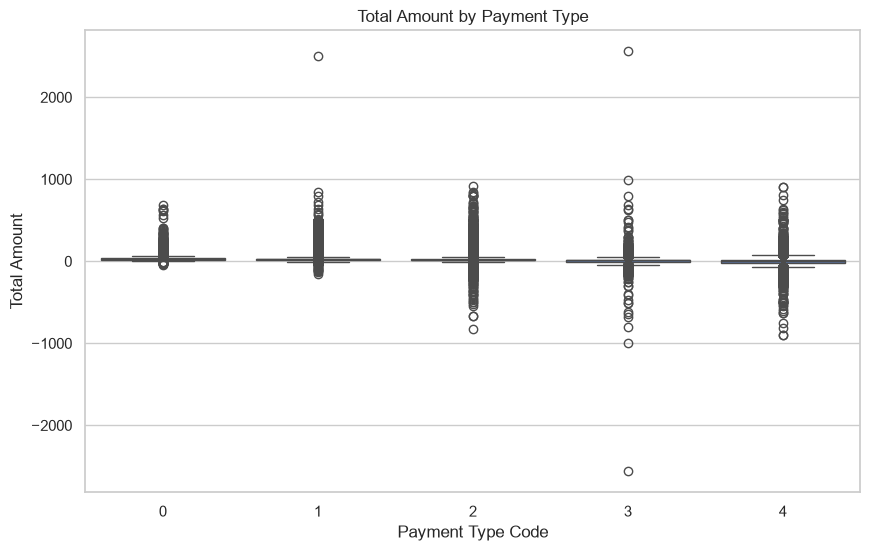

In [16]:
#Payment type vs total amount
payment_amount = df[["payment_type", "total_amount"]].dropna()

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=payment_amount,
    x="payment_type",
    y="total_amount"
)
plt.title("Total Amount by Payment Type")
plt.xlabel("Payment Type Code")
plt.ylabel("Total Amount")
plt.show()

In [17]:
display(
    payment_amount.groupby("payment_type")["total_amount"]
    .agg(["count", "median", "mean", "std"])
    .sort_index()
)

,count,median,mean,std
payment_type,,,,
0,1088058,28.08,31.683795,15.979875
1,2249746,21.90,29.610534,23.212712
2,314043,17.50,23.411882,24.994022
3,16641,10.55,8.927758,48.521087
4,56400,8.00,1.698764,43.668678


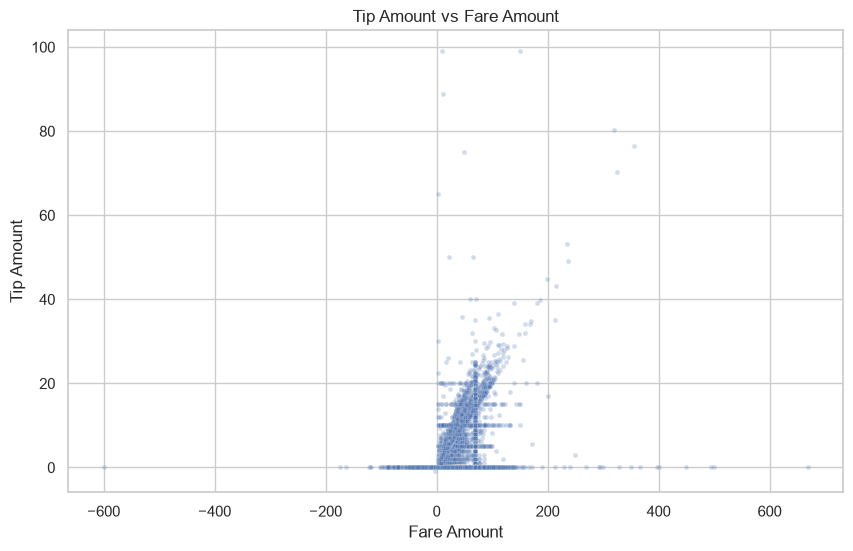

In [18]:
#Tip amount vs fare amount
tip_fare = df[["fare_amount", "tip_amount"]].dropna()

sample = tip_fare.sample(
    n=min(50_000, len(tip_fare)),
    random_state=42
)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=sample,
    x="fare_amount",
    y="tip_amount",
    alpha=0.25,
    s=12
)
plt.title("Tip Amount vs Fare Amount")
plt.xlabel("Fare Amount")
plt.ylabel("Tip Amount")
plt.show()

In [19]:
print(
    "Pearson:",
    tip_fare["fare_amount"].corr(tip_fare["tip_amount"], method="pearson")
)

print(
    "Spearman:",
    tip_fare["fare_amount"].rank().corr(tip_fare["tip_amount"].rank(), method="spearman")
)

Pearson: 0.37600271993472595
Spearman: 0.017462725618965426


## Correlation overview

In [21]:
correlation_columns = [
    "trip_distance",
    "fare_amount",
    "total_amount",
    "tip_amount",
    "tolls_amount",
    duration_column
]

correlation_columns = [
    column for column in correlation_columns
    if column in df.columns
]

correlation_matrix = df[correlation_columns].rank().corr(method="spearman")

display(correlation_matrix)

,trip_distance,fare_amount,total_amount,tip_amount,tolls_amount,trip_duration_minutes
trip_distance,1.000000,0.760579,0.750409,0.101607,0.357424,0.766013
fare_amount,0.760579,1.000000,0.958888,0.017463,0.369886,0.848370
total_amount,0.750409,0.958888,1.000000,0.190706,0.393865,0.833707
tip_amount,0.101607,0.017463,0.190706,1.000000,0.155982,0.075572
tolls_amount,0.357424,0.369886,0.393865,0.155982,1.000000,0.315744
trip_duration_minutes,0.766013,0.848370,0.833707,0.075572,0.315744,1.000000


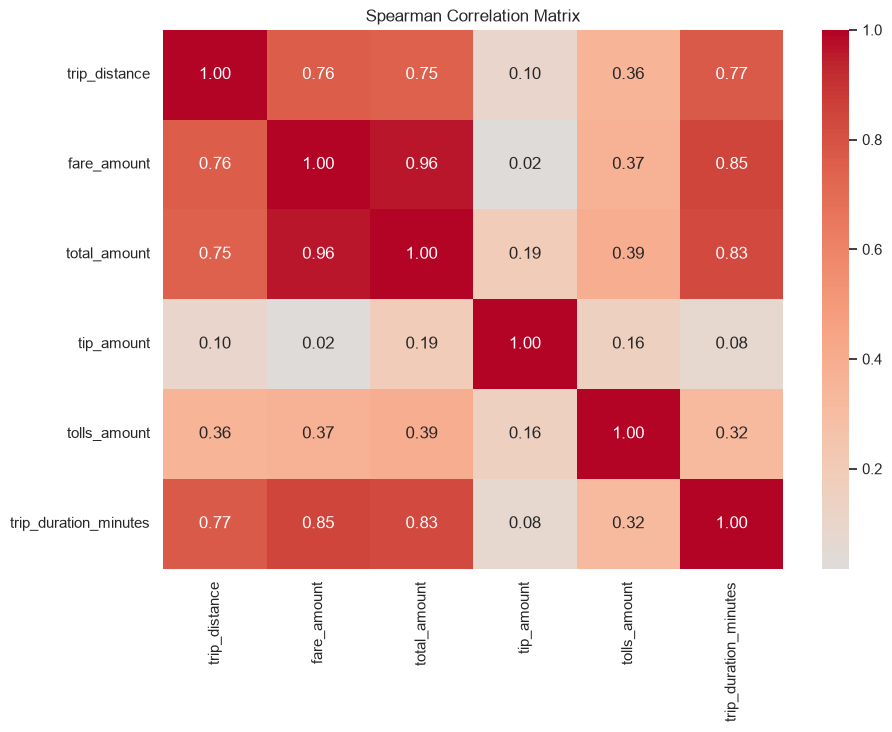

In [22]:
plt.figure(figsize=(10, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    center=0
)
plt.title("Spearman Correlation Matrix")
plt.show()

### Trip Distance — Findings

Trip distance is strongly right-skewed. The mean trip distance is
approximately 6.46 miles, while the median is 1.81 miles, indicating
that larger trips pull the mean upward.

The 99th percentile is approximately 19.54 miles, while the maximum
recorded distance is 269,097.48 miles. Investigation of the maximum
observation shows that the trip lasted only 8 minutes and has an
implied average speed of approximately 2,018,231 mph. The recorded
fare is also only $12.19.

Therefore, the maximum observation is highly anomalous and is not
consistent with a plausible taxi journey. It should be flagged and
excluded from analyses where unrealistic trip distances would distort
the results, while retaining the original record for traceability.

The IQR is approximately 2.71 miles. Under the 1.5 × IQR rule,
observations above the upper fence are statistical outliers. However,
these observations are not automatically invalid; legitimate
long-distance taxi trips may also appear as statistical outliers.

# Financial Analysis


In [4]:
financial_columns = [
    "fare_amount",
    "extra",
    "mta_tax",
    "tip_amount",
    "tolls_amount",
    "improvement_surcharge",
    "congestion_surcharge",
    "Airport_fee",
    "cbd_congestion_fee",
    "total_amount"
]

financial_columns = [
    col for col in financial_columns
    if col in df.columns
]

display(df[financial_columns].describe().T)

,count,mean,std,min,25%,50%,75%,max
fare_amount,3724888.0,20.804242,18.926995,-2555.20,10.0,15.60,26.10,2555.20
extra,3724888.0,1.023055,1.707322,-7.50,0.0,0.00,2.50,17.46
mta_tax,3724888.0,0.483377,0.114556,-0.50,0.5,0.50,0.50,4.75
tip_amount,3724888.0,2.608143,3.917405,-88.88,0.0,2.00,3.71,766.00
tolls_amount,3724888.0,0.498375,2.131731,-94.50,0.0,0.00,0.00,122.22
improvement_surcharge,3724888.0,0.947913,0.265485,-1.00,1.0,1.00,1.00,1.00
congestion_surcharge,2636830.0,2.154871,0.942364,-2.50,2.5,2.50,2.50,2.50
Airport_fee,2636830.0,0.148294,0.533671,-1.75,0.0,0.00,0.00,26.75
cbd_congestion_fee,3724888.0,0.519644,0.356810,-0.75,0.0,0.75,0.75,0.75
total_amount,3724888.0,29.178515,22.585524,-2560.20,17.0,23.05,33.83,2560.20


### Total amount vs fare amount

In [5]:
df["additional_charges"] = (
    df["total_amount"] - df["fare_amount"]
)

In [6]:
df["additional_charges"].describe()

count    3.724888e+06
mean     8.374274e+00
std      6.304050e+00
min     -9.825000e+01
25%      4.750000e+00
50%      7.500000e+00
75%      9.800000e+00
max      7.675000e+02
Name: additional_charges, dtype: float64

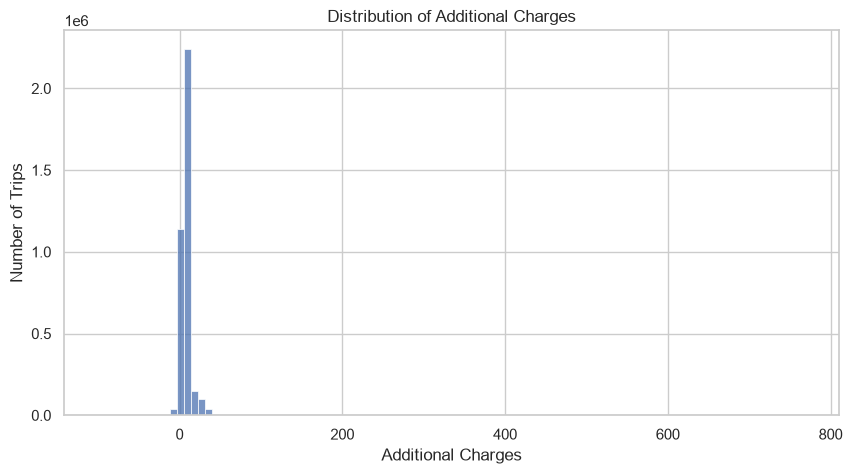

In [7]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["additional_charges"].dropna(),
    bins=100
)

plt.title("Distribution of Additional Charges")
plt.xlabel("Additional Charges")
plt.ylabel("Number of Trips")

plt.show()

### Tip analysis

In [9]:
tip_analysis = df[
    (df["fare_amount"] > 0) &
    (df["tip_amount"] >= 0)
].copy()

In [10]:
tip_analysis["tip_percentage"] = (
    tip_analysis["tip_amount"] /
    tip_analysis["fare_amount"]
) * 100

In [11]:
tip_analysis["tip_percentage"].describe(
    percentiles=[.25, .5, .75, .90, .95, .99]
)

count    3.683343e+06
mean     1.610265e+01
std      1.781978e+02
min      0.000000e+00
25%      0.000000e+00
50%      1.538462e+01
75%      2.843137e+01
90%      3.461538e+01
95%      3.964602e+01
99%      5.230769e+01
max      3.000000e+05
Name: tip_percentage, dtype: float64

### Tipping by payment type

In [12]:
display(
    tip_analysis.groupby("payment_type")["tip_amount"]
    .agg(["count", "mean", "median", "sum"])
)

,count,mean,median,sum
payment_type,,,,
0,1087491,0.375229,0.00,408058.04
1,2249456,4.137563,3.16,9307266.66
2,304203,0.000395,0.00,120.29
3,12005,0.000217,0.00,2.60
4,30188,0.002985,0.00,90.12


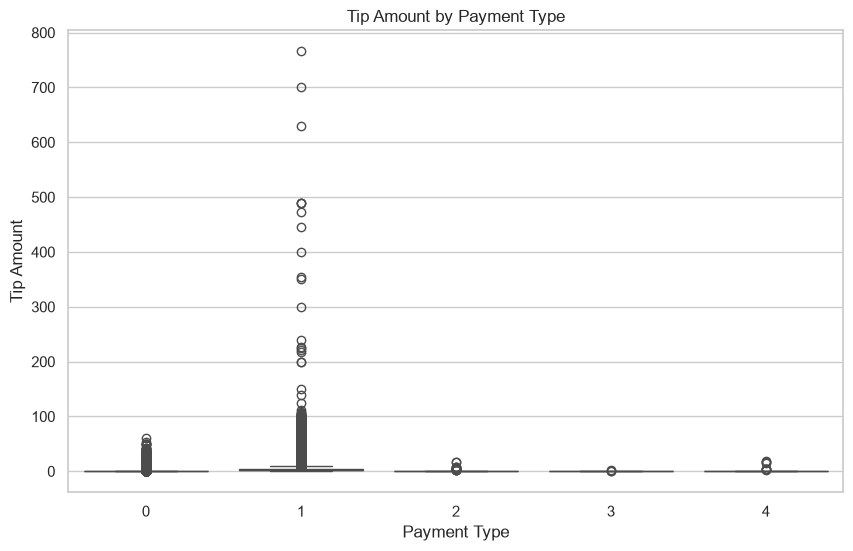

In [13]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=tip_analysis,
    x="payment_type",
    y="tip_amount"
)

plt.title("Tip Amount by Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("Tip Amount")

plt.show()

### Revenue by trip distance

In [14]:
distance_bins = pd.cut(
    df["trip_distance"],
    bins=[0, 1, 2, 3, 5, 10, 20, 50, np.inf]
)

In [15]:
distance_fare_summary = (
    df.groupby(distance_bins, observed=False)
    .agg(
        trips=("trip_distance", "size"),
        median_fare=("fare_amount", "median"),
        mean_fare=("fare_amount", "mean"),
        median_total=("total_amount", "median"),
        mean_total=("total_amount", "mean")
    )
)

display(distance_fare_summary)

,trips,median_fare,mean_fare,median_total,mean_total
trip_distance,,,,,
"(0.0, 1.0]",814511,7.2,9.275556,14.700,16.071436
"(1.0, 2.0]",1084747,12.1,13.093044,19.650,20.450460
"(2.0, 3.0]",548705,17.0,18.720260,25.250,26.449425
"(3.0, 5.0]",458120,23.2,24.762690,31.330,32.633934
"(5.0, 10.0]",413556,33.1,34.193884,41.750,44.505400
"(10.0, 20.0]",248309,56.2,55.636035,74.750,72.211719
"(20.0, 50.0]",30582,70.0,82.373219,99.500,103.192341
"(50.0, inf]",620,259.8,206.585468,300.175,233.140823


### Fare per mile

In [16]:
df["fare_per_mile"].describe(
    percentiles=[.25, .5, .75, .90, .95, .99]
)

count    3.599150e+06
mean     2.641476e+01
std      2.730409e+02
min     -3.990000e+04
25%      5.661376e+00
50%      7.500000e+00
75%      9.885057e+00
90%      1.342105e+01
95%      1.750473e+01
99%      7.352941e+01
max      4.900000e+04
Name: fare_per_mile, dtype: float64

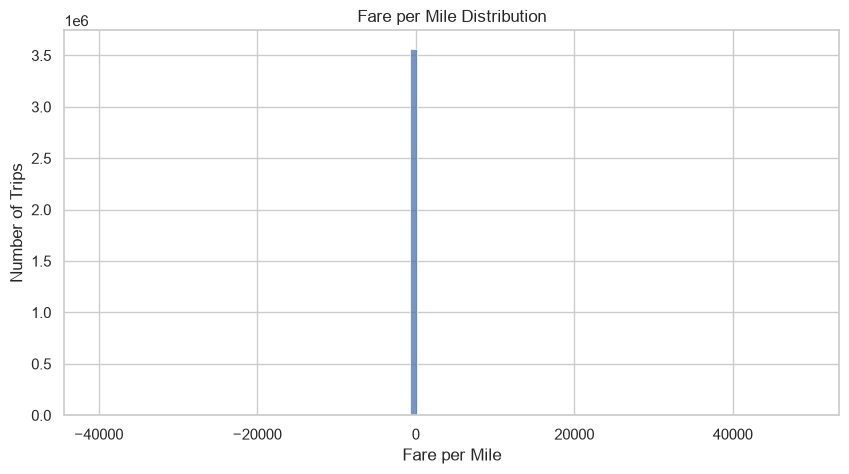

In [17]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["fare_per_mile"].dropna(),
    bins=100
)

plt.title("Fare per Mile Distribution")
plt.xlabel("Fare per Mile")
plt.ylabel("Number of Trips")

plt.show()

## Financial Analysis — Key Findings
1. Fare and Total Amount
The distribution of fare_amount is right-skewed, with a mean of $20.80 and a median of $15.60.
The distribution of total_amount is right-skewed, with a mean of $29.18 and a median of $23.05.
The difference between total_amount and fare_amount represents additional recorded charges such as tips, taxes, surcharges, and other applicable fees.
Extreme values were observed in the financial variables and were considered when interpreting the distributions.

2. Additional Charges
Additional recorded charges show a right-skewed distribution.
The median additional charge is $7.50, while the mean is $8.37.
The distribution indicates that high values pull the mean above the median; negative and extreme values are also present.

3. Tipping Behavior
42.3% of valid trips had a recorded tip of zero.
Among valid trips with a positive fare, the median tip percentage was 15.4%.
Tip amounts showed a moderate positive linear association with fare amount (Pearson correlation ≈ 0.38).
The results suggest that larger fares generally are associated with larger tip amounts, although this represents an association rather than causation.

4. Payment Type and Tips
Tip amounts differed across payment-type groups.
Payment type 1 had the highest mean recorded tip of $4.14 and the highest median recorded tip of $3.16.
However, differences between payment groups should not be interpreted as the payment method causing differences in tipping behavior because other characteristics of the trips may differ between groups.

5. Distance and Financial Value
Median and mean fare generally increased as trip-distance category increased.
Shorter trips contributed the most trips, while longer trips showed higher fares and total amounts per trip.
Fare-per-mile was particularly sensitive to very small distances and anomalous trip-distance records, so extreme observations require careful interpretation.
Overall Finding
The financial analysis shows that taxi-trip charges are influenced by multiple recorded components rather than the base fare alone. Fare, total amount, tips, additional charges, and trip distance exhibit different distributions and relationships. Extreme observations and unusual trip records can substantially affect financial metrics, so robust statistics and appropriate filtering/flagging are important when interpreting the results.

# Temporal Analysis

### Trips by Hour

In [18]:
hourly_trips = (
    df.groupby("pickup_hour")
    .size()
    .reset_index(name="trip_count")
)

display(hourly_trips)

,pickup_hour,trip_count
0,0,111867
1,1,77821
2,2,54105
3,3,38645
4,4,28673
5,5,32912
6,6,63721
7,7,113463
8,8,148281
9,9,156894


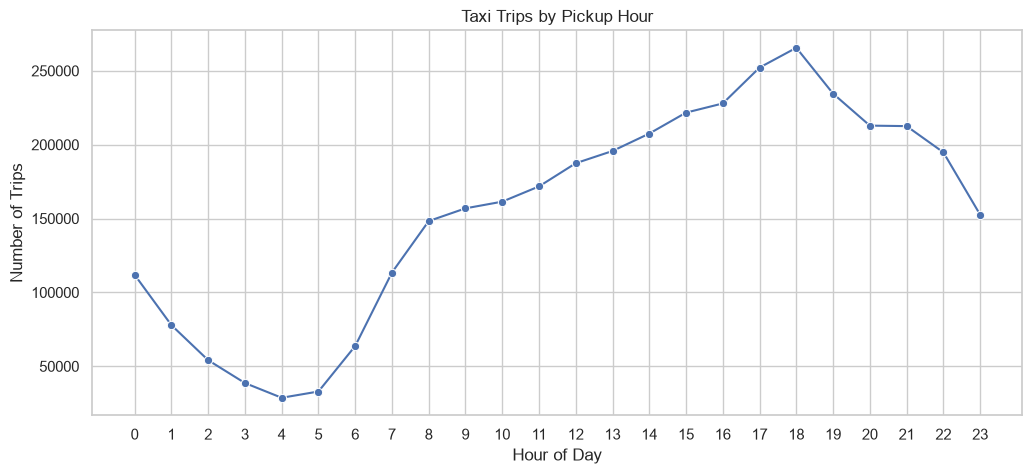

In [19]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=hourly_trips,
    x="pickup_hour",
    y="trip_count",
    marker="o"
)

plt.title("Taxi Trips by Pickup Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.xticks(range(24))

plt.show()

#### We can see that at hour 18:00 maximum number trips were taken. Hour 4:00 redcorded the minimum number of trips.

#### Also the demand is mostly concentrated towards the evening section.

## busiest and quietest hours

In [20]:
hourly_trips.sort_values(
    "trip_count",
    ascending=False
).head(10)

,pickup_hour,trip_count
18,18,265574
17,17,252173
19,19,234541
16,16,227893
15,15,221677
20,20,212883
21,21,212544
14,14,207507
13,13,195708
22,22,194801


In [21]:
hourly_trips.sort_values(
    "trip_count",
    ascending=True
).head(10)

,pickup_hour,trip_count
4,4,28673
5,5,32912
3,3,38645
2,2,54105
6,6,63721
1,1,77821
0,0,111867
7,7,113463
8,8,148281
23,23,152622


## Average trip distance by hour

In [22]:
hourly_distance = (
    df.groupby("pickup_hour")["trip_distance"]
    .agg(["count", "mean", "median"])
    .reset_index()
)

display(hourly_distance)

,pickup_hour,count,mean,median
0,0,111867,4.750537,2.47
1,1,77821,8.247310,2.38
2,2,54105,9.167202,2.42
3,3,38645,9.912448,2.65
4,4,28673,7.501011,3.20
5,5,32912,15.211518,3.62
6,6,63721,9.265857,3.01
7,7,113463,17.346660,2.31
8,8,148281,8.680368,1.98
9,9,156894,7.422044,1.80


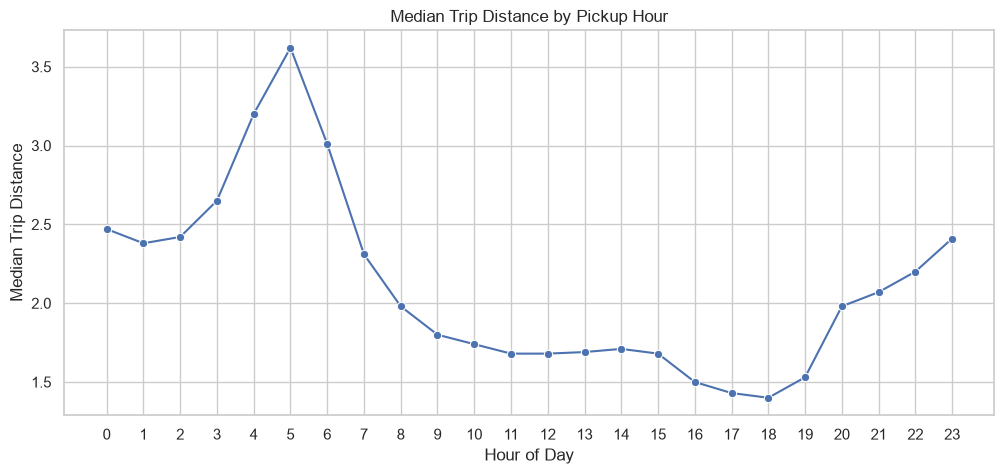

In [23]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=hourly_distance,
    x="pickup_hour",
    y="median",
    marker="o"
)

plt.title("Median Trip Distance by Pickup Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Median Trip Distance")

plt.xticks(range(24))

plt.show()

## Trip duration by hour

In [24]:
hourly_duration = (
    df.groupby("pickup_hour")["trip_duration_minutes"]
    .agg(["count", "mean", "median"])
    .reset_index()
)

display(hourly_duration)

,pickup_hour,count,mean,median
0,0,111867,14.974479,12.716667
1,1,77821,14.099284,12.166667
2,2,54105,13.660911,11.883333
3,3,38645,13.769027,12.000000
4,4,28673,15.795707,12.833333
5,5,32912,19.552443,13.350000
6,6,63721,21.074865,13.283333
7,7,113463,19.818448,13.333333
8,8,148281,18.724940,13.750000
9,9,156894,17.926087,13.383333


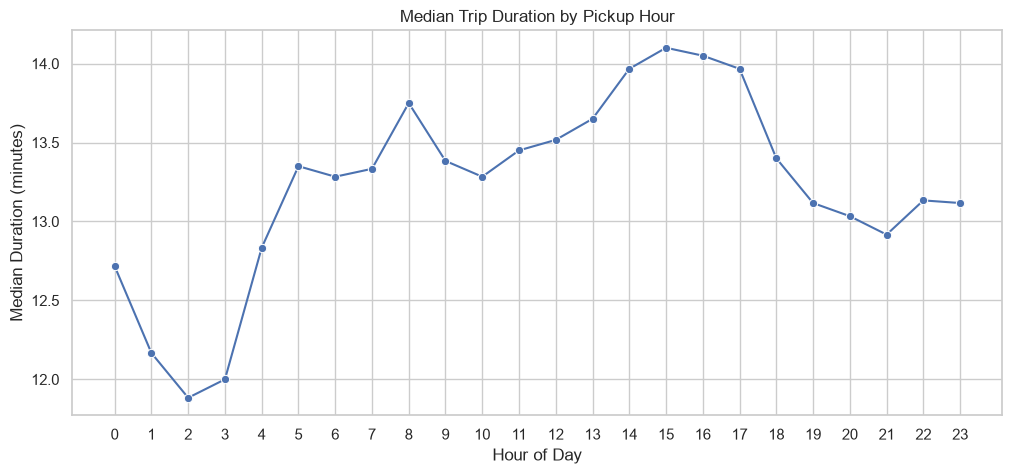

In [25]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=hourly_duration,
    x="pickup_hour",
    y="median",
    marker="o"
)

plt.title("Median Trip Duration by Pickup Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Median Duration (minutes)")

plt.xticks(range(24))

plt.show()

#### We can infer from graphic that even though hour 5:00 had the more longer distances travelled recorded but at hour 15:00 the trip durations were higher, this can lead us to some deductions that at hour 15:00 maybe due to high traffic the trip duration were higher.

## Fare by hour

In [26]:
hourly_fare = (
    df.groupby("pickup_hour")["fare_amount"]
    .agg(["count", "mean", "median"])
    .reset_index()
)

display(hourly_fare)

,pickup_hour,count,mean,median
0,0,111867,21.526300,17.19
1,1,77821,21.366547,17.00
2,2,54105,20.208237,16.30
3,3,38645,20.724355,17.00
4,4,28673,23.836083,19.49
5,5,32912,26.338968,20.50
6,6,63721,25.370419,19.10
7,7,113463,23.642552,17.23
8,8,148281,22.343495,16.34
9,9,156894,20.362261,15.20


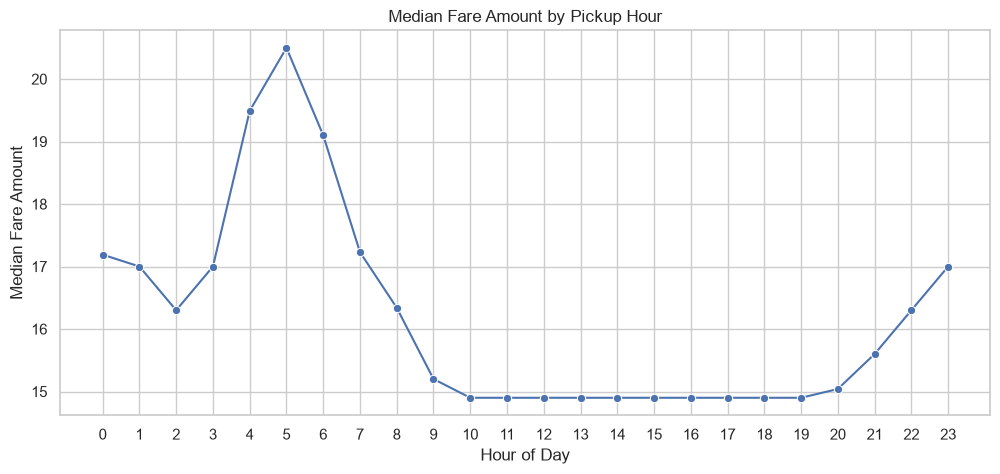

In [27]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=hourly_fare,
    x="pickup_hour",
    y="median",
    marker="o"
)

plt.title("Median Fare Amount by Pickup Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Median Fare Amount")

plt.xticks(range(24))

plt.show()

#### We can see that at hout 5:00 the fare amount is maximum as it should be as the the trip distances were higher during those hours.


#### Here is a graph showing the median of fare amount and median of trip distance vs hour of the day

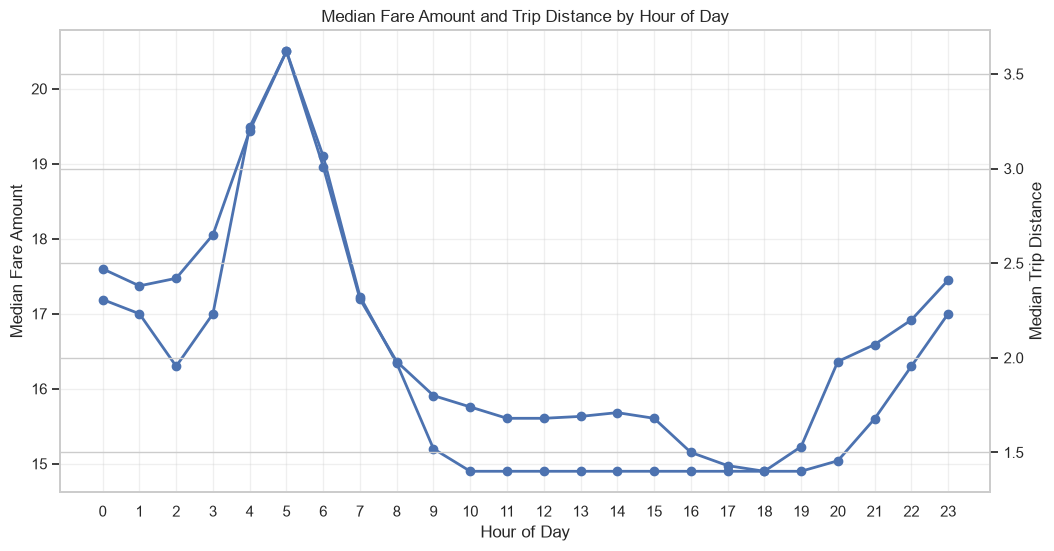

In [29]:
# Median fare amount and trip distance by hour of day

plot_df = df[
    ["tpep_pickup_datetime", "fare_amount", "trip_distance"]
].dropna()

# Extract hour
plot_df["hour"] = plot_df["tpep_pickup_datetime"].dt.hour

# Calculate hourly medians
hourly_median = (
    plot_df
    .groupby("hour")
    .agg(
        median_fare=("fare_amount", "median"),
        median_distance=("trip_distance", "median")
    )
    .reset_index()
)

# Create figure
fig, ax1 = plt.subplots(figsize=(12, 6))

# Fare amount
ax1.plot(
    hourly_median["hour"],
    hourly_median["median_fare"],
    marker="o",
    linewidth=2,
    label="Median Fare Amount"
)

ax1.set_xlabel("Hour of Day")
ax1.set_ylabel("Median Fare Amount")
ax1.set_xticks(range(24))
ax1.grid(alpha=0.3)

# Trip distance on second y-axis
ax2 = ax1.twinx()

ax2.plot(
    hourly_median["hour"],
    hourly_median["median_distance"],
    marker="o",
    linewidth=2,
    label="Median Trip Distance"
)

ax2.set_ylabel("Median Trip Distance")

plt.title("Median Fare Amount and Trip Distance by Hour of Day")

plt.show()

## Day-of-week analysis

In [30]:
daily_trips = (
    df.groupby(["pickup_weekday", "pickup_day_name"])
    .size()
    .reset_index(name="trip_count")
    .sort_values("pickup_weekday")
)

display(daily_trips)

,pickup_weekday,pickup_day_name,trip_count
0,0,Monday,379436
1,1,Tuesday,483387
2,2,Wednesday,505678
3,3,Thursday,655343
4,4,Friday,655242
5,5,Saturday,672151
6,6,Sunday,373651


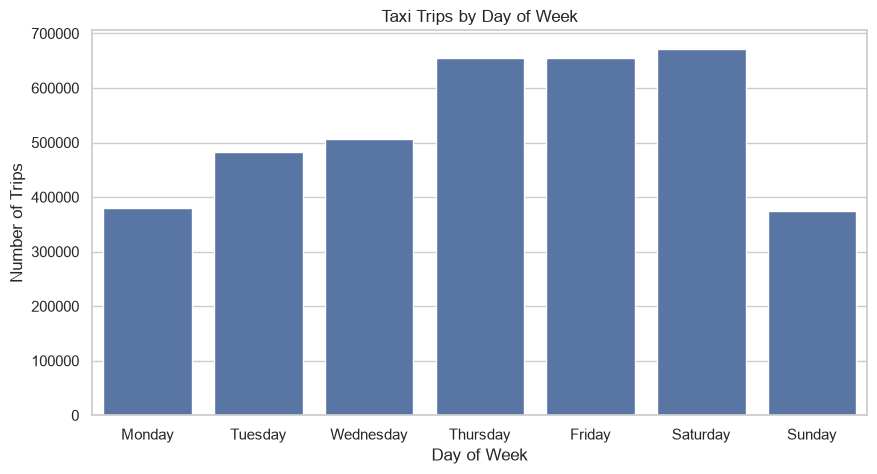

In [31]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=daily_trips,
    x="pickup_day_name",
    y="trip_count"
)

plt.title("Taxi Trips by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Trips")

plt.show()

#### We can infer that Saturday recorded the more number of trips.

## Weekday vs Weekend

In [32]:
weekend_summary = (
    df.groupby("is_weekend")
    .agg(
        trips=("trip_distance", "size"),
        median_distance=("trip_distance", "median"),
        median_duration=("trip_duration_minutes", "median"),
        median_fare=("fare_amount", "median"),
        median_total=("total_amount", "median")
    )
)

display(weekend_summary)

,trips,median_distance,median_duration,median_fare,median_total
is_weekend,,,,,
False,2679086,1.77,13.650000,15.60,23.5
True,1045802,1.97,12.683333,15.09,22.0


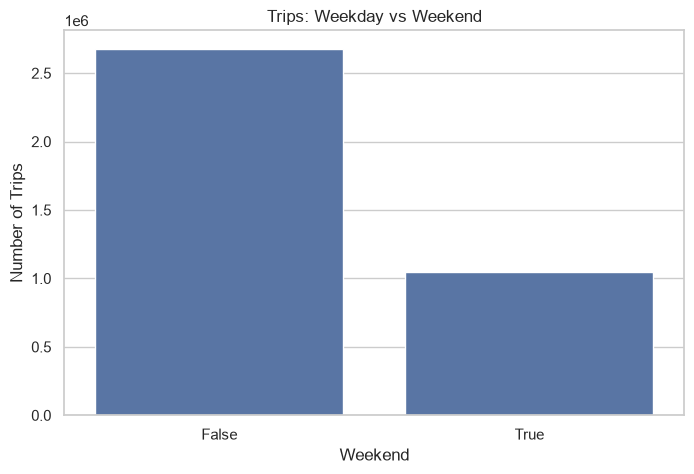

In [33]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="is_weekend",
    y="trip_distance",
    estimator="count",
    errorbar=None
)

plt.title("Trips: Weekday vs Weekend")
plt.xlabel("Weekend")
plt.ylabel("Number of Trips")

plt.show()

## Hour × Day

In [34]:
hour_day = pd.crosstab(
    df["pickup_day_name"],
    df["pickup_hour"]
)

hour_day

pickup_hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
pickup_day_name,,,,,,,,,,,,,,,,,,,,,
Friday,15190,8362,5157,3450,3478,6205,12081,21426,26333,26960,...,36797,39435,40520,44507,48484,44624,37354,37305,39358,36564
Monday,7800,3881,2357,1738,2038,3675,7417,13093,17679,18142,...,24112,25409,25720,27432,28016,22939,20845,20105,15495,11872
Saturday,31530,24910,17804,12255,7572,4299,6178,8682,13905,20113,...,35346,38326,40672,42182,44965,43422,36751,35317,40838,38719
Sunday,26091,19844,14818,10305,5772,3053,4438,6061,8304,11886,...,21664,21161,21931,21964,22116,19049,16944,15829,15215,11927
Thursday,17358,14048,10178,8188,6092,6941,12846,23058,28630,28348,...,34582,37664,38162,44022,46471,40391,39013,40992,35117,25298
Tuesday,6799,3236,1916,1340,1887,4562,10207,20095,26135,25489,...,27164,29455,30134,35613,36594,30587,30350,30554,22885,13025
Wednesday,7099,3540,1875,1369,1834,4177,10554,21048,27295,25956,...,27842,30227,30754,36453,38928,33529,31626,32442,25893,15217


In [35]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

hour_day = hour_day.reindex(day_order)

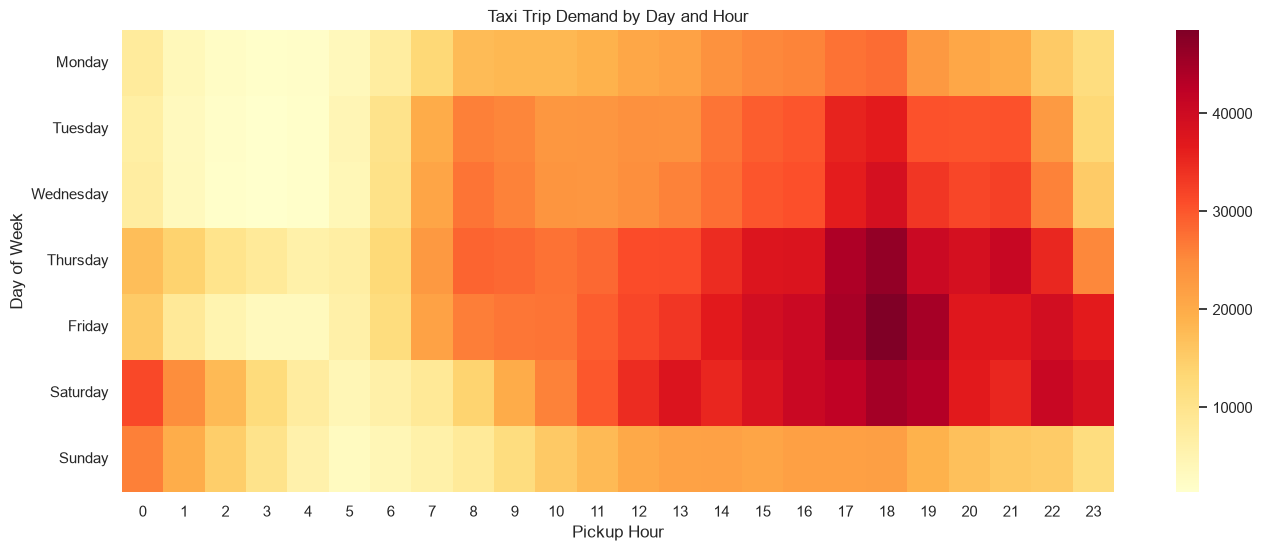

In [36]:
plt.figure(figsize=(16, 6))

sns.heatmap(
    hour_day,
    cmap="YlOrRd"
)

plt.title("Taxi Trip Demand by Day and Hour")
plt.xlabel("Pickup Hour")
plt.ylabel("Day of Week")

plt.show()

#### We can see that the most trips were recorded on thursday, friday and saturday at hour 18:00.

## Hour × Weekend

In [38]:
# Make sure pickup datetime is actually datetime
df["tpep_pickup_datetime"] = pd.to_datetime(
    df["tpep_pickup_datetime"]
)

# Extract hour
df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour

# Create weekday/weekend classification
df["day_type"] = np.where(
    df["tpep_pickup_datetime"].dt.dayofweek < 5,
    "Weekday",
    "Weekend"
)

In [39]:
hour_daytype = (
    df.groupby(["day_type", "pickup_hour"])
    .size()
    .reset_index(name="trip_count")
)

display(hour_daytype)

,day_type,pickup_hour,trip_count
0,Weekday,0,54246
1,Weekday,1,33067
2,Weekday,2,21483
3,Weekday,3,16085
4,Weekday,4,15329
5,Weekday,5,25560
6,Weekday,6,53105
7,Weekday,7,98720
8,Weekday,8,126072
9,Weekday,9,124895


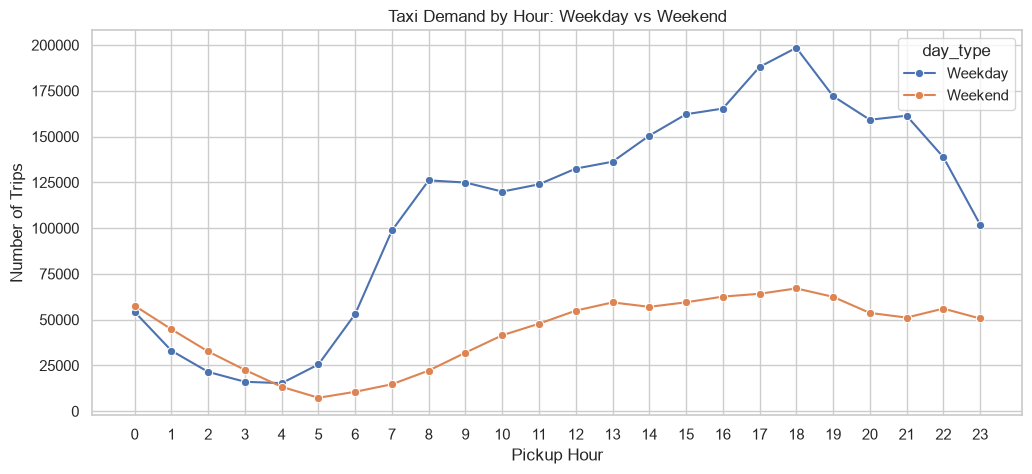

In [40]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=hour_daytype,
    x="pickup_hour",
    y="trip_count",
    hue="day_type",
    marker="o"
)

plt.title("Taxi Demand by Hour: Weekday vs Weekend")
plt.xlabel("Pickup Hour")
plt.ylabel("Number of Trips")
plt.xticks(range(24))

plt.show()

## Temporal Analysis — Key Findings
1. Hourly Demand
- The number of taxi trips varies substantially across the day.
- The busiest observed hour was 18:00 (6 PM), with 265,574 trips.
- The quietest observed hour was 04:00 (4 AM), with 28,673 trips.
- The overall hourly pattern shows demand rising through the day, peaking in the early evening, and being lowest during the early morning hours.
2. Trip Characteristics
- Median trip distance varies across pickup hours, ranging from approximately 1.40 to 3.62 miles.
- Median trip duration varies across the day, with the lowest median around 2 AM (11.88 minutes) and the highest around 3 PM (14.10 minutes).
- Median fare varies by pickup hour, with the highest around 5 AM ($20.50) and lower medians of about $14.90 from 10 AM to 7 PM.
3. Weekly Pattern
- The highest trip volume occurred on Saturday (672,151 trips).
- The lowest trip volume occurred on Sunday (373,651 trips).
- Weekday and weekend trips differ in volume and trip characteristics: weekend trips had a slightly higher median distance and shorter median duration, while weekday trips had higher median fares and total amounts.
4. Hour × Day Pattern
- The hour-by-day heatmap reveals strong evening demand, particularly around 6 PM, with Friday, Thursday, and Saturday among the busiest day-hour combinations.
- Weekday demand shows morning activity that builds into a pronounced evening peak around 5–6 PM.
- Weekend demand shows stronger late-night activity, an early-morning lull, and rising demand through the day toward an evening peak.
5. Temporal Limitation
- The dataset covers January 2026; therefore, conclusions about long-term seasonality and month-to-month trends are not reliable from this single month of data